In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch 
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets,transforms,models


import os

from torch.utils.data import random_split,DataLoader,Dataset

In [2]:
# Applying Transformation
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.Lambda(lambda img: img.convert("L")),   #L mean to GrayScale   RCB mean to Colorful image
    transforms.ToTensor(),   #dont have to use permute
    transforms.Normalize([0.5]*1, [0.5]*1)   #*1 cause grayscale have 1 chanel only 3 if rgb
])

In [3]:

datas = datasets.ImageFolder(root="cat vs Dog",transform=transform)

In [4]:

train_size = int(0.8 * len(datas))
test_size = len(datas) - train_size

train_data, test_data = random_split(datas, [train_size, test_size])

In [5]:
train_data = DataLoader(train_data,batch_size=16,drop_last=False,shuffle=True,pin_memory=True)
test_data = DataLoader(test_data,batch_size=16,drop_last=False,shuffle=False,pin_memory=True)


In [6]:
print(f"Train Batch : {len(train_data)}")

print("Test Batch : ",len(test_data))

Train Batch : 58
Test Batch :  15


In [7]:
for img,label in train_data:
    print(img.shape)
    break


# Format ===> (batch,chunk = Grayscale ,height,width


torch.Size([16, 1, 100, 100])


In [8]:
# Image in each block
i=0
for img,label in train_data:
    print(f"Image Batch{i+1}", img)
    i+=1
    


Image Batch1 tensor([[[[-0.5137, -0.5059, -0.4980,  ..., -0.6941, -0.6235, -0.6471],
          [-0.5059, -0.4902, -0.4824,  ..., -0.6941, -0.5294, -0.6157],
          [-0.4824, -0.4745, -0.4588,  ..., -0.5529, -0.4039, -0.6000],
          ...,
          [-0.4353, -0.3804, -0.1686,  ...,  0.1294, -0.0745, -0.0824],
          [-0.4824, -0.4118, -0.2157,  ...,  0.1373, -0.0667, -0.0980],
          [-0.5137, -0.4196, -0.2706,  ...,  0.1137, -0.0588, -0.1137]]],


        [[[-0.2314,  0.1843,  0.3255,  ...,  0.4588,  0.3882,  0.3412],
          [ 0.0510,  0.3490,  0.3725,  ...,  0.3176,  0.3569,  0.5608],
          [ 0.0353,  0.2549,  0.4510,  ...,  0.8667,  0.8588,  0.8510],
          ...,
          [ 0.1686,  0.1216,  0.4510,  ..., -0.5294, -0.5608, -0.7255],
          [ 0.3098,  0.4039,  0.6078,  ..., -0.6157, -0.5294, -0.6627],
          [ 0.4431,  0.3569,  0.4588,  ..., -0.6392, -0.5529, -0.7647]]],


        [[[ 0.6078,  0.6078,  0.6078,  ...,  0.4275,  0.4275,  0.4196],
          [ 0

/home/darshan/miniconda3/envs/py_gpu/lib/python3.10/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Image Batch39 tensor([[[[ 1.0000,  1.0000,  1.0000,  ...,  0.7882,  0.8039,  0.7882],
          [ 1.0000,  1.0000,  1.0000,  ...,  0.7882,  0.8039,  0.7882],
          [ 1.0000,  1.0000,  1.0000,  ...,  0.7804,  0.7961,  0.7882],
          ...,
          [ 1.0000,  1.0000,  1.0000,  ...,  0.4980,  0.4824,  0.4745],
          [ 1.0000,  1.0000,  1.0000,  ...,  0.4902,  0.4667,  0.4745],
          [ 1.0000,  1.0000,  1.0000,  ...,  0.4824,  0.4588,  0.4510]]],


        [[[-0.3490, -0.2863, -0.0824,  ..., -0.2078, -0.2392, -0.2549],
          [-0.2078, -0.2627, -0.1216,  ..., -0.2863, -0.3412, -0.3098],
          [-0.1451, -0.2314, -0.2627,  ..., -0.2078, -0.3490, -0.3961],
          ...,
          [-0.8118, -0.7804, -0.8353,  ..., -0.8745, -0.8980, -0.9137],
          [-0.8275, -0.8275, -0.8745,  ..., -0.8824, -0.9059, -0.9216],
          [-0.8118, -0.8510, -0.8902,  ..., -0.8824, -0.9137, -0.9294]]],


        [[[-0.4588,  0.0824,  0.4431,  ...,  0.7490,  0.7490,  0.7098],
          [-

In [9]:
# label in each block
i=0
for img,label in train_data:
    print(f"Image Labels Batch{i+1}", label)
    i+=1
    

Image Labels Batch1 tensor([0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0])
Image Labels Batch2 tensor([1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1])
Image Labels Batch3 tensor([1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0])
Image Labels Batch4 tensor([1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1])
Image Labels Batch5 tensor([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1])
Image Labels Batch6 tensor([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])
Image Labels Batch7 tensor([1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1])
Image Labels Batch8 tensor([1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1])
Image Labels Batch9 tensor([1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0])
Image Labels Batch10 tensor([0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0])
Image Labels Batch11 tensor([0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1])
Image Labels Batch12 tensor([0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1])
Image Labels Batch13 tensor([1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,

In [10]:
i = 0
for img, label in train_data:
    print(f"Image {i+1} shape:", img.shape)
    i += 1
    break


    # Format need to change for  (batch,chunk,h,w)  ====>(batch,h,w,c)

Image 1 shape: torch.Size([16, 1, 100, 100])


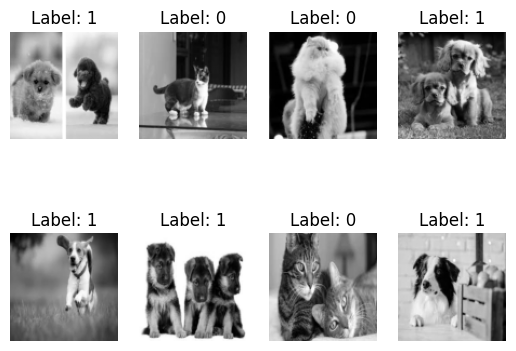

In [11]:
images, labels = next(iter(train_data))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

plt.show()

In [12]:
class CNN_Architecture(nn.Module):
    def __init__(self):
        super() .__init__()


        # cnn architecture


        # Key formulas  == ⌊N+2P−K/S⌋+1   new shape 
        # Max pool   (n-k/s)+1

        self.model = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3),
                                    # Input: (1, 100, 100)
                                    # Conv: 100 - 3 + 1 = 98 → (16, 98, 98)
                                    
                                    nn.ReLU(),
                                    
                                    nn.MaxPool2d(2),
                                    # Pool: 98 / 2 = 49 → (16, 49, 49)
                                    
                                    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
                                    # Conv: 49 - 3 + 1 = 47 → (32, 47, 47)
                                    
                                    nn.ReLU(),
                                    
                                    nn.MaxPool2d(2),
                                    # Pool: 47 / 2 = 23.5 → floor → 23 → (32, 23, 23)
                                    
                                    # Final tensor = (32, 23, 23)
                                    
                                    # Flatten:
                                    # 32 × 23 × 23 = 16928
                                    
                                    nn.Flatten(),
                                    nn.Linear(32*23*23,128),
                                    nn.ReLU(),
                                    nn.Linear(128,2)
                                  )


    def forward(self,x):
        return self.model(x)
        
        

In [13]:
# using model 

# 1st defining model

model = CNN_Architecture()


# PREPARING GPU for Fast Accleration

device = ('cuda' if torch.cuda.get_device_name() else 'cpu')


# connectiong model and GPU 

model.to(device)


# Declaring Loss function

criterion = nn.CrossEntropyLoss()


# optimizer
optimizer = optim.Adam(model.parameters(),lr=1e-3)

# Declaring Epoch for training
epochs  =15

In [14]:
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):


    model.train()
    total_loss = 0

    for X, y in train_data:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = criterion(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_data)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}")

    model.eval()
    total_loss_val = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_val, y_val in test_data:
            X_val, y_val = X_val.to(device), y_val.to(device)

            y_pred_val = model(X_val)
            loss_val = criterion(y_pred_val, y_val)

            total_loss_val += loss_val.item()

            # Accuracy
            _, preds = torch.max(y_pred_val, 1)
            correct += (preds == y_val).sum().item()
            total += y_val.size(0)

    avg_loss_val = total_loss_val / len(test_data)
    accuracy = 100 * correct / total

    val_losses.append(avg_loss_val)
    val_accuracies.append(accuracy)

    print(f"Validation Loss: {avg_loss_val:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")
    print("="*60)

Epoch 1, Train Loss: 0.6991
Validation Loss: 0.6417
Validation Accuracy: 63.64%
Epoch 2, Train Loss: 0.6180
Validation Loss: 0.6279
Validation Accuracy: 66.23%
Epoch 3, Train Loss: 0.5128
Validation Loss: 0.5890
Validation Accuracy: 70.56%
Epoch 4, Train Loss: 0.3698
Validation Loss: 0.6669
Validation Accuracy: 64.50%
Epoch 5, Train Loss: 0.2376
Validation Loss: 0.7981
Validation Accuracy: 70.13%
Epoch 6, Train Loss: 0.1094
Validation Loss: 1.0611
Validation Accuracy: 64.07%
Epoch 7, Train Loss: 0.0705
Validation Loss: 1.3326
Validation Accuracy: 71.00%
Epoch 8, Train Loss: 0.0272
Validation Loss: 1.4386
Validation Accuracy: 67.10%
Epoch 9, Train Loss: 0.0226
Validation Loss: 1.3621
Validation Accuracy: 68.83%
Epoch 10, Train Loss: 0.0209
Validation Loss: 1.4746
Validation Accuracy: 71.00%
Epoch 11, Train Loss: 0.0165
Validation Loss: 1.4611
Validation Accuracy: 69.70%
Epoch 12, Train Loss: 0.0101
Validation Loss: 1.6395
Validation Accuracy: 68.83%
Epoch 13, Train Loss: 0.0163
Validati

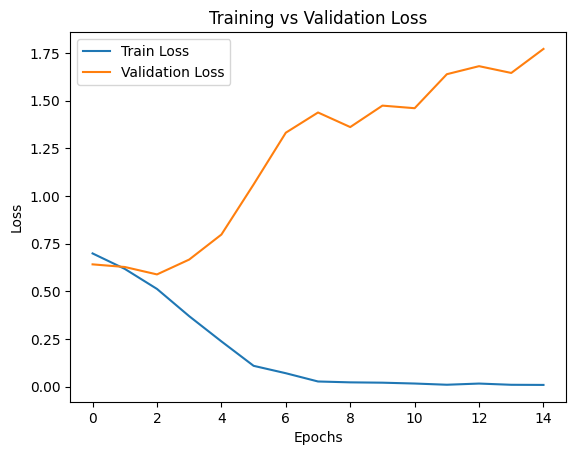

In [15]:
plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [16]:
# Debugging Block
train_losses

[0.6991247709455162,
 0.6179848380129913,
 0.5127946811503378,
 0.36983917473719036,
 0.23758938060752277,
 0.10935633658463585,
 0.0705298381969975,
 0.027206249936515915,
 0.022638897907293946,
 0.02090432186779598,
 0.016479766469023285,
 0.010116698902806845,
 0.016315367860129458,
 0.009871458900181158,
 0.009176554656858509]

# Few parameter tuining

In [17]:

class CNN_Architecture(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

         
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

       
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [18]:
model = CNN_Architecture()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criteration = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 15

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for X, y in train_data:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = criteration(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_data)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}")

    # Validation
    model.eval()
    total_loss_val = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_val, y_val in test_data:
            X_val, y_val = X_val.to(device), y_val.to(device)

            y_pred_val = model(X_val)
            loss_val = criteration(y_pred_val, y_val)

            total_loss_val += loss_val.item()

            _, preds = torch.max(y_pred_val, 1)
            correct += (preds == y_val).sum().item()
            total += y_val.size(0)

    avg_loss_val = total_loss_val / len(test_data)
    accuracy = 100 * correct / total

    val_losses.append(avg_loss_val)
    val_accuracies.append(accuracy)

    print(f"Validation Loss: {avg_loss_val:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")
    print("="*60)

Epoch 1, Train Loss: 0.7694
Validation Loss: 0.6762
Validation Accuracy: 61.04%
Epoch 2, Train Loss: 0.5991
Validation Loss: 0.7424
Validation Accuracy: 53.25%
Epoch 3, Train Loss: 0.5724
Validation Loss: 0.6003
Validation Accuracy: 67.53%
Epoch 4, Train Loss: 0.4698
Validation Loss: 0.5812
Validation Accuracy: 70.13%
Epoch 5, Train Loss: 0.4036
Validation Loss: 0.5488
Validation Accuracy: 74.46%
Epoch 6, Train Loss: 0.3483
Validation Loss: 0.5232
Validation Accuracy: 75.76%
Epoch 7, Train Loss: 0.2893
Validation Loss: 0.5623
Validation Accuracy: 74.03%
Epoch 8, Train Loss: 0.2144
Validation Loss: 0.5488
Validation Accuracy: 75.32%
Epoch 9, Train Loss: 0.1775
Validation Loss: 0.5203
Validation Accuracy: 75.76%
Epoch 10, Train Loss: 0.1236
Validation Loss: 0.5586
Validation Accuracy: 74.89%
Epoch 11, Train Loss: 0.0933
Validation Loss: 0.5498
Validation Accuracy: 74.46%
Epoch 12, Train Loss: 0.0721
Validation Loss: 0.5789
Validation Accuracy: 74.03%
Epoch 13, Train Loss: 0.0610
Validati

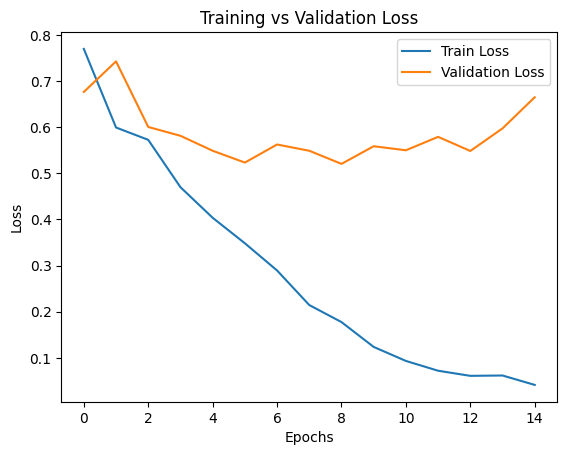

In [19]:
plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [20]:
device = ('cuda' if torch.cuda.get_device_name() else 'cpu')

device

'cuda'

# Using RGB IMAGE ON SAME Parameter 

In [21]:
# Applying Transformation
transform = transforms.Compose([
    transforms.Resize((130, 130)),
    transforms.Lambda(lambda img: img.convert("RGB")),   
    transforms.ToTensor(),   #dont have to use permute
    transforms.Normalize([0.5]*3, [0.5]*3)   
])

In [22]:

datas = datasets.ImageFolder(root="cat vs Dog",transform=transform)



train_size = int(0.8 * len(datas))
test_size = len(datas) - train_size

train_data, test_data = random_split(datas, [train_size, test_size])



train_data = DataLoader(train_data,batch_size=16,drop_last=False,shuffle=True,pin_memory=True)
test_data = DataLoader(test_data,batch_size=16,drop_last=False,shuffle=False,pin_memory=True)



i = 0
for img, label in train_data:
    print(f"Image {i+1} shape:", img.shape)
    i += 1
    break


    # Format need to change for  (batch,chunk,h,w)  ====>(batch,h,w,c)

Image 1 shape: torch.Size([16, 3, 130, 130])


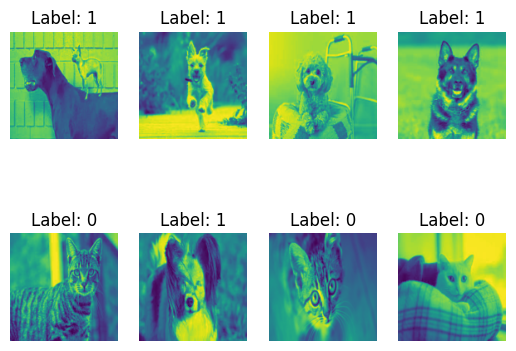

In [23]:
images, labels = next(iter(train_data))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0])
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

plt.show()

In [24]:
class CNN_Architecture(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)), 
            nn.Flatten(),

            nn.Linear(128, 256),       
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [25]:
model = CNN_Architecture()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criteration = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 15

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for X, y in train_data:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = criteration(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_data)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}")

    # Validation
    model.eval()
    total_loss_val = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_val, y_val in test_data:
            X_val, y_val = X_val.to(device), y_val.to(device)

            y_pred_val = model(X_val)
            loss_val = criteration(y_pred_val, y_val)

            total_loss_val += loss_val.item()

            _, preds = torch.max(y_pred_val, 1)
            correct += (preds == y_val).sum().item()
            total += y_val.size(0)

    avg_loss_val = total_loss_val / len(test_data)
    accuracy = 100 * correct / total

    val_losses.append(avg_loss_val)
    val_accuracies.append(accuracy)

    print(f"Validation Loss: {avg_loss_val:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")
    print("="*60)
    

Epoch 1, Train Loss: 0.6692
Validation Loss: 0.6352
Validation Accuracy: 61.90%
Epoch 2, Train Loss: 0.6530
Validation Loss: 0.6378
Validation Accuracy: 65.80%
Epoch 3, Train Loss: 0.6430
Validation Loss: 0.6324
Validation Accuracy: 66.23%
Epoch 4, Train Loss: 0.6363
Validation Loss: 0.6205
Validation Accuracy: 67.53%
Epoch 5, Train Loss: 0.6334
Validation Loss: 0.6440
Validation Accuracy: 66.23%
Epoch 6, Train Loss: 0.6209
Validation Loss: 0.6306
Validation Accuracy: 66.23%
Epoch 7, Train Loss: 0.6268
Validation Loss: 0.6106
Validation Accuracy: 66.23%
Epoch 8, Train Loss: 0.6207
Validation Loss: 0.6063
Validation Accuracy: 65.80%
Epoch 9, Train Loss: 0.6136
Validation Loss: 0.6298
Validation Accuracy: 67.10%
Epoch 10, Train Loss: 0.6147
Validation Loss: 0.5964
Validation Accuracy: 66.67%
Epoch 11, Train Loss: 0.6008
Validation Loss: 0.5955
Validation Accuracy: 67.53%
Epoch 12, Train Loss: 0.6021
Validation Loss: 0.5862
Validation Accuracy: 71.00%
Epoch 13, Train Loss: 0.6098
Validati

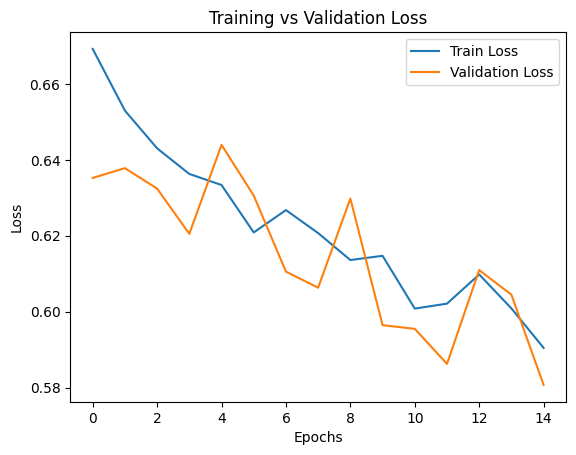

In [26]:
plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()


# Now using VGG16

In [27]:
# Mean ,Std (Normalization)  and shape shoud be constant cause model cnn feature exytacter is trained on same dataset

transform = transforms.Compose([transforms.Resize((224,224)),
                                transforms.Lambda(lambda  img :img.convert('RGB')),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485,0.456,0.402],std=[0.229,0.224,0.225]),
                                
                               ])
                                
                                                  

In [28]:
datas = datasets.ImageFolder(root="cat vs Dog",transform=transform)

In [29]:
# Debug data
len(datas)

1153

In [30]:
# Train Validation Split
# 8:2 ratio

train_size = int(0.8 * len(datas))
test_size = len(datas) - train_size

train_data, test_data = random_split(datas, [train_size, test_size])



In [31]:
# Batching Data
train_data = DataLoader(train_data,batch_size=32,shuffle=True,num_workers=4,pin_memory=True)
test_data = DataLoader(test_data,batch_size=32,shuffle=False,num_workers = 4 ,pin_memory=True)


    

In [32]:
print(f"Total Train Batch {len(train_data)}       Total Test Data {len(test_data)}")

Total Train Batch 29       Total Test Data 8


In [33]:
i = 1
for img,target in train_data:
    print(f"Batch : {i}   Targets {target}")
    i+=1

Batch : 1   Targets tensor([0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 0, 1, 1])
Batch : 2   Targets tensor([0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
        0, 0, 1, 1, 1, 1, 1, 1])
Batch : 3   Targets tensor([1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        0, 1, 1, 0, 0, 0, 1, 1])
Batch : 4   Targets tensor([1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
        1, 0, 1, 0, 0, 1, 0, 0])
Batch : 5   Targets tensor([0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
        1, 1, 1, 0, 1, 0, 1, 1])
Batch : 6   Targets tensor([1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
        1, 0, 1, 0, 1, 1, 1, 0])
Batch : 7   Targets tensor([1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
        0, 0, 0, 0, 1, 1, 0, 1])
Batch : 8   Targets tensor([1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,

In [34]:
i = 1
for img,target in train_data:
    if i < 3:
        print(f"Batch : {i}   Targets {img}")
        i+=1

    else:
        break
    

# USing Break cause data is to large

Batch : 1   Targets tensor([[[[-1.0733, -0.6452, -0.6623,  ...,  1.0502,  1.0502,  1.0331],
          [-1.3130, -0.9705, -0.6281,  ...,  1.0502,  1.0502,  1.0331],
          [-1.5357, -1.2617, -0.6965,  ...,  1.0502,  1.0502,  1.0331],
          ...,
          [ 0.9132,  0.9474,  0.9646,  ...,  0.6906,  0.6906,  0.6906],
          [ 0.9474,  0.9646,  0.9817,  ...,  0.6906,  0.6906,  0.6906],
          [ 0.9646,  0.9817,  0.9988,  ...,  0.6906,  0.6906,  0.6906]],

         [[-0.9328, -0.5126, -0.5301,  ...,  1.1856,  1.1856,  1.1681],
          [-1.1779, -0.8452, -0.4951,  ...,  1.1856,  1.1856,  1.1681],
          [-1.3880, -1.1078, -0.5476,  ...,  1.1856,  1.1856,  1.1681],
          ...,
          [ 0.6429,  0.6779,  0.7129,  ...,  0.6604,  0.6604,  0.6604],
          [ 0.6779,  0.6954,  0.7304,  ...,  0.6604,  0.6604,  0.6604],
          [ 0.6954,  0.7129,  0.7479,  ...,  0.6604,  0.6604,  0.6604]],

         [[-0.2529,  0.0957, -0.0612,  ...,  1.3506,  1.3506,  1.3332],
          

In [35]:
model = models.vgg16(weights="IMAGENET1K_V1")

model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [36]:
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224))      #batch is give 1  as a dummy batch to visulize the dataStructure (MOdel structure)

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 1000]                 --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          29

In [37]:
# Wt and bias of model

i=1
for paras in model.parameters():
    if i <3:
        print(paras)
        i+=1
    else:
        break

Parameter containing:
tensor([[[[-5.5373e-01,  1.4270e-01,  5.2896e-01],
          [-5.8312e-01,  3.5655e-01,  7.6566e-01],
          [-6.9022e-01, -4.8019e-02,  4.8409e-01]],

         [[ 1.7548e-01,  9.8630e-03, -8.1413e-02],
          [ 4.4089e-02, -7.0323e-02, -2.6035e-01],
          [ 1.3239e-01, -1.7279e-01, -1.3226e-01]],

         [[ 3.1303e-01, -1.6591e-01, -4.2752e-01],
          [ 4.7519e-01, -8.2677e-02, -4.8700e-01],
          [ 6.3203e-01,  1.9308e-02, -2.7753e-01]]],


        [[[ 2.3254e-01,  1.2666e-01,  1.8605e-01],
          [-4.2805e-01, -2.4349e-01,  2.4628e-01],
          [-2.5066e-01,  1.4177e-01, -5.4864e-03]],

         [[-1.4076e-01, -2.1903e-01,  1.5041e-01],
          [-8.4127e-01, -3.5176e-01,  5.6398e-01],
          [-2.4194e-01,  5.1928e-01,  5.3915e-01]],

         [[-3.1432e-01, -3.7048e-01, -1.3094e-01],
          [-4.7144e-01, -1.5503e-01,  3.4589e-01],
          [ 5.4384e-02,  5.8683e-01,  4.9580e-01]]],


        [[[ 1.7715e-01,  5.2149e-01,  9.8740

In [38]:
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [39]:
for name, param in model.named_parameters():
    print(name, param.shape)

features.0.weight torch.Size([64, 3, 3, 3])
features.0.bias torch.Size([64])
features.2.weight torch.Size([64, 64, 3, 3])
features.2.bias torch.Size([64])
features.5.weight torch.Size([128, 64, 3, 3])
features.5.bias torch.Size([128])
features.7.weight torch.Size([128, 128, 3, 3])
features.7.bias torch.Size([128])
features.10.weight torch.Size([256, 128, 3, 3])
features.10.bias torch.Size([256])
features.12.weight torch.Size([256, 256, 3, 3])
features.12.bias torch.Size([256])
features.14.weight torch.Size([256, 256, 3, 3])
features.14.bias torch.Size([256])
features.17.weight torch.Size([512, 256, 3, 3])
features.17.bias torch.Size([512])
features.19.weight torch.Size([512, 512, 3, 3])
features.19.bias torch.Size([512])
features.21.weight torch.Size([512, 512, 3, 3])
features.21.bias torch.Size([512])
features.24.weight torch.Size([512, 512, 3, 3])
features.24.bias torch.Size([512])
features.26.weight torch.Size([512, 512, 3, 3])
features.26.bias torch.Size([512])
features.28.weight t

In [40]:
model.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [41]:
# Disabiling Model Features mean CNN layers

for param in model.features.parameters():
    param.requires_grad =False


for param in model.classifier.parameters():
    param.requires_grad = False
    

In [42]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

features.0.weight False
features.0.bias False
features.2.weight False
features.2.bias False
features.5.weight False
features.5.bias False
features.7.weight False
features.7.bias False
features.10.weight False
features.10.bias False
features.12.weight False
features.12.bias False
features.14.weight False
features.14.bias False
features.17.weight False
features.17.bias False
features.19.weight False
features.19.bias False
features.21.weight False
features.21.bias False
features.24.weight False
features.24.bias False
features.26.weight False
features.26.bias False
features.28.weight False
features.28.bias False
classifier.0.weight False
classifier.0.bias False
classifier.3.weight False
classifier.3.bias False
classifier.6.weight False
classifier.6.bias False


In [43]:
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [50]:
# Building own classifier



# WE HAVE modified  no of neuron to prevent over fit and final layer cause we have only 2 output class

model.avgpool = nn.AdaptiveAvgPool2d((1,1))

model.classifier = nn.Sequential(
    nn.Linear(512, 128), 
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2)
)

In [51]:
summary(model, input_size=(1, 3, 224, 224)) 

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 2]                    --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         (36,928)
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        (73,856)
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        (147,584)
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]    

In [52]:
model.to(device)


criteration = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr = 1e-4)


epochs = 15

train_losses = []
val_losses = []

for epoch in range (epochs):
    model.train()
    total_loss = 0
    for x,y in train_data:
        x = x.to(device)
        y = y.to(device)
# Flow --> y_hat ----->loss ----->optimize(Backward pass)
        
        # y_hat
        y_pred = model(x)

        # loss
        loss = criteration(y_pred,y)

        # Reset all wt and bias before updating wt and bias in next back prop
        optimizer.zero_grad()
        
        # backpass
        loss.backward()

        # updating wt and bias

        optimizer.step()


        # Calculating total loss on that batch
        total_loss +=loss.item()


    avg_loss = total_loss/len(train_data)
    train_losses.append(avg_loss)
    
    print("=="*20)
    print(f"Train  Loss: {avg_loss:.4f}")

    


    # Now runnign val loop sideby side to check model Status
    model.eval()
    total_loss_val = 0
    
    with torch.no_grad():
        for X,Y in test_data:
            X = X.to(device)
            Y = Y.to(device)
    
            # Same flow but in evaluation we dont do backpass we use obtain wt from backpass in forward pass
    
            # y_hat -->loss
    
            y_hat = model(X)
    
    
            # Loss
            loss = criteration(y_hat,Y)
    
    
            total_loss_val += loss.item()


        avg_loss_val = total_loss_val/len(test_data)
        val_losses.append(avg_loss_val)

        
        print(f"Validation Loss: {avg_loss_val:.4f}")
        print("=="*20)
        



    model.train()

        

        

        

        
    

Train  Loss: 0.5880
Validation Loss: 0.4911
Train  Loss: 0.4073
Validation Loss: 0.3482
Train  Loss: 0.2992
Validation Loss: 0.2573
Train  Loss: 0.2287
Validation Loss: 0.2017
Train  Loss: 0.1801
Validation Loss: 0.1673
Train  Loss: 0.1612
Validation Loss: 0.1428
Train  Loss: 0.1377
Validation Loss: 0.1270
Train  Loss: 0.1216
Validation Loss: 0.1143
Train  Loss: 0.1187
Validation Loss: 0.1061
Train  Loss: 0.1032
Validation Loss: 0.0979
Train  Loss: 0.0998
Validation Loss: 0.0923
Train  Loss: 0.0924
Validation Loss: 0.0886
Train  Loss: 0.0864
Validation Loss: 0.0854
Train  Loss: 0.0843
Validation Loss: 0.0834
Train  Loss: 0.0828
Validation Loss: 0.0818


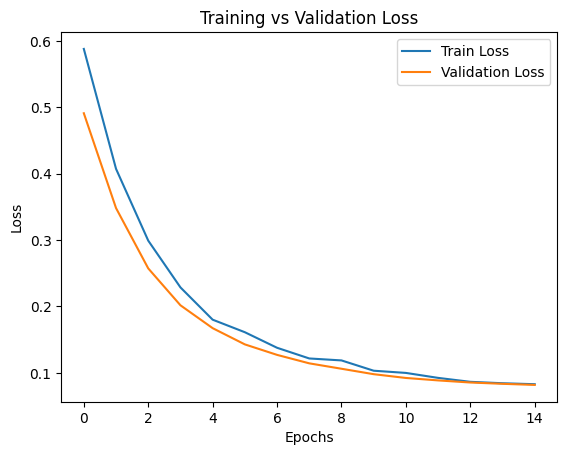

In [53]:
plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

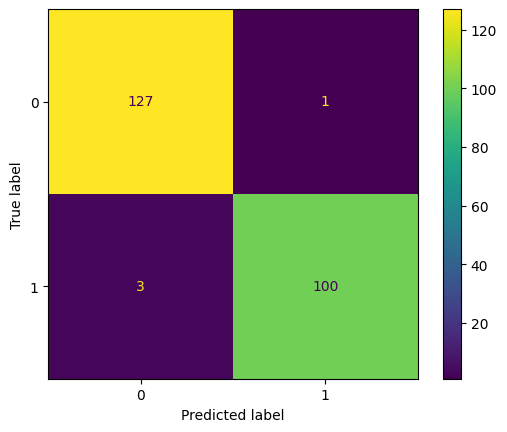

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for X, y in test_data:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        prob = torch.softmax(outputs, dim=1)[:,1]
        probs.extend(prob.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [66]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=["Cat", "Dog"]))

              precision    recall  f1-score   support

         Cat       0.98      0.99      0.98       128
         Dog       0.99      0.97      0.98       103

    accuracy                           0.98       231
   macro avg       0.98      0.98      0.98       231
weighted avg       0.98      0.98      0.98       231



In [67]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(all_labels, all_preds))

Accuracy: 0.9826839826839827


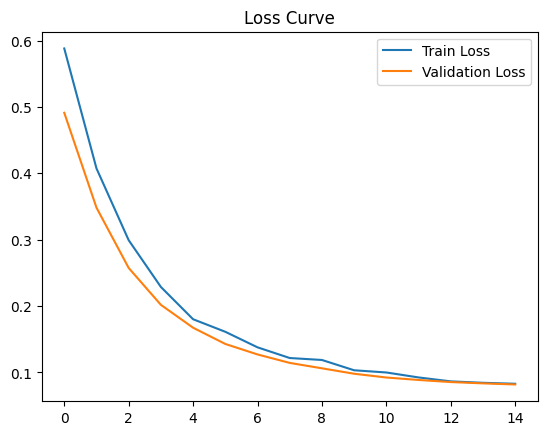

In [68]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6403487].


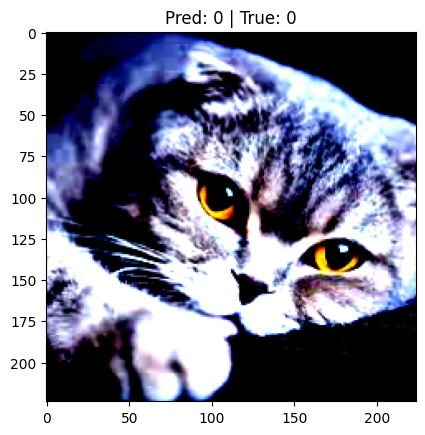

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].


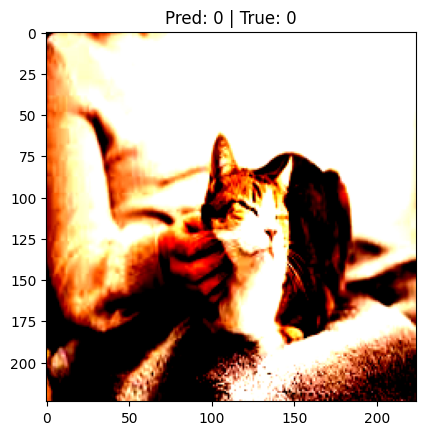

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..2.6403487].


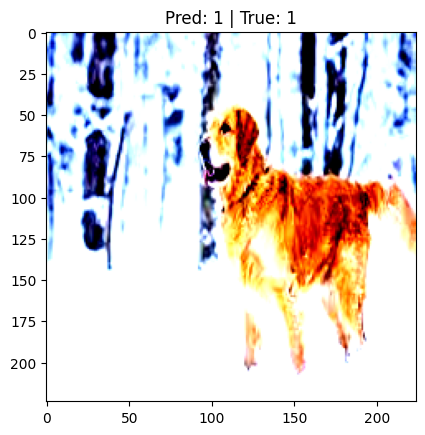

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.2489083].


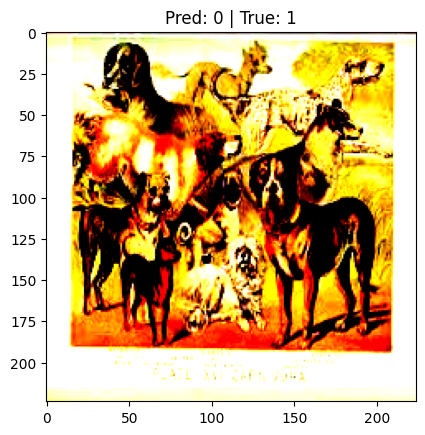

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.6403487].


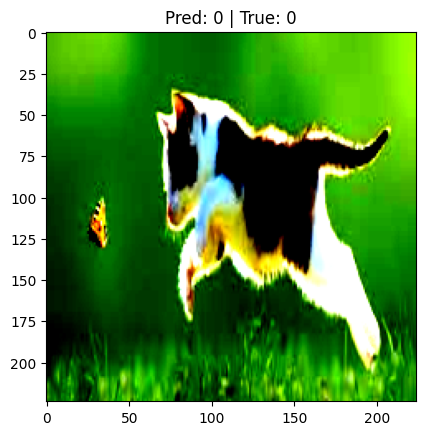

In [69]:
# Visulizing where model make mistake in which image

import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(test_data))

with torch.no_grad():
    outputs = model(images.to(device))
    _, preds = torch.max(outputs, 1)

for i in range(5):
    plt.imshow(images[i].permute(1,2,0))
    plt.title(f"Pred: {preds[i].item()} | True: {labels[i].item()}")
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.2489083].


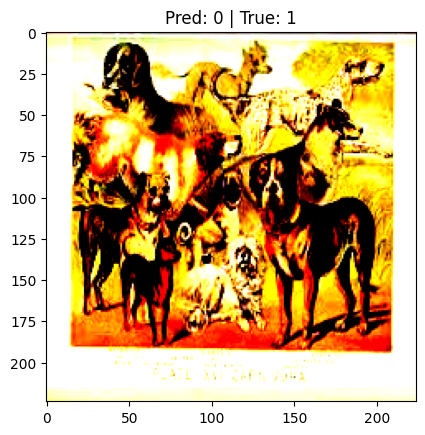

In [83]:
# Visulizing Only Mistakes



images, labels = next(iter(test_data))

with torch.no_grad():
    outputs = model(images.to(device))
    _, preds = torch.max(outputs, 1)

for i in range(len(images)):
    if preds[i] != labels[i]:   
        plt.imshow(images[i].permute(1,2,0))
        plt.title(f"Pred: {preds[i].item()} | True: {labels[i].item()}")
        plt.show()

In [70]:
# Checking class Imbalance

from collections import Counter
labels = Counter(all_labels)
print(labels)

Counter({np.int64(0): 128, np.int64(1): 103})


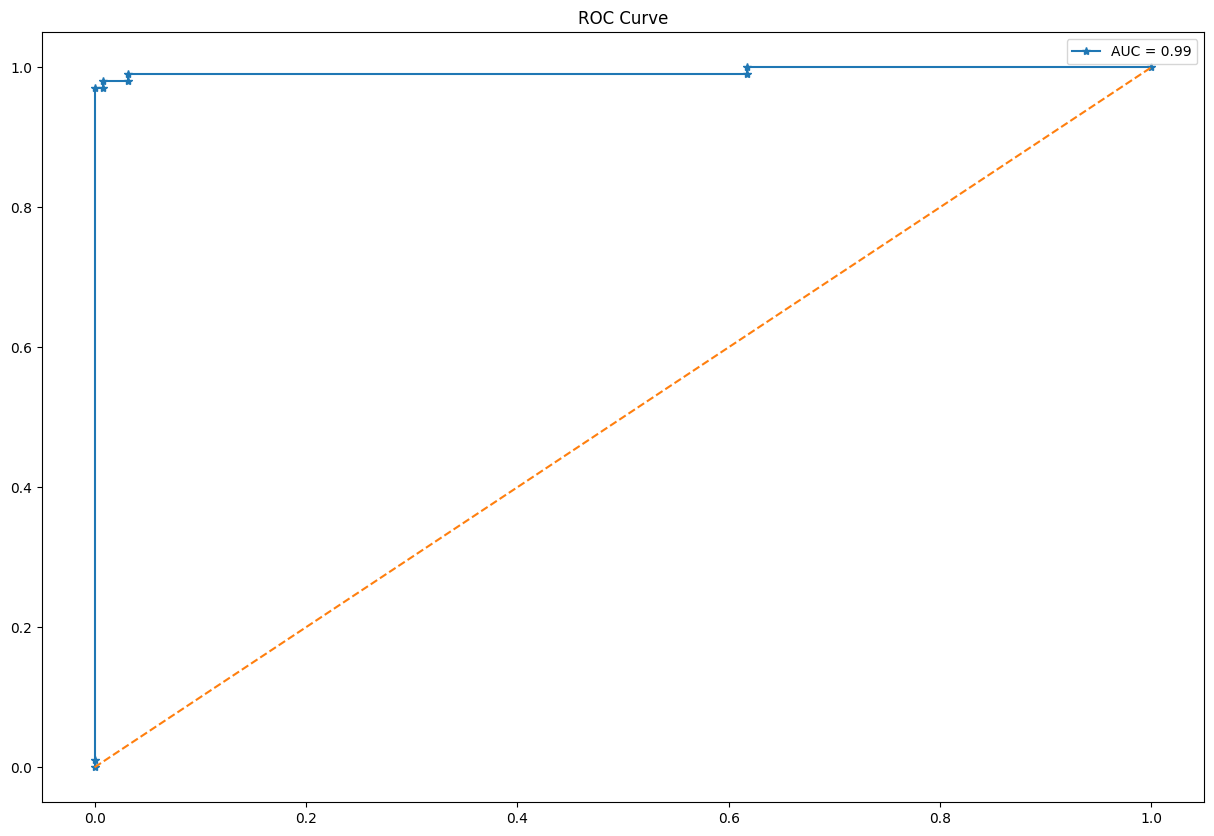

In [80]:
from sklearn.metrics import roc_curve, auc

probs = []
model.eval()

with torch.no_grad():
    for X, _ in test_data:
        X = X.to(device)
        outputs = model(X)
        prob = torch.softmax(outputs, dim=1)[:,1]
        probs.extend(prob.cpu().numpy())

fpr, tpr, _ = roc_curve(all_labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(15,10))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}",marker = "*")
plt.plot([0,1], [0,1], linestyle='--')
plt.legend()
plt.title("ROC Curve")
plt.show()


# Let X be investment and Y be profit and chose a profit where investment is less

# Prediction function

In [81]:
def predict(model, image, device):
    model.eval()

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return pred.item()

In [88]:
from PIL import Image
# Prediction Flow
# load img --->apply transformation ------>give image Gpu

image = Image.open("cat vs Dog/cat_test.jpg").convert("RGB")

image = transform(image)

image = image.to(device)


y_pred = predict(model,image,device)

if y_pred == 0:
    labels = 'Cat'

else:
    labels = 'Dog'


print(f"Given image is identified as : {labels}")


Given image is identified as  Cat


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.588061].


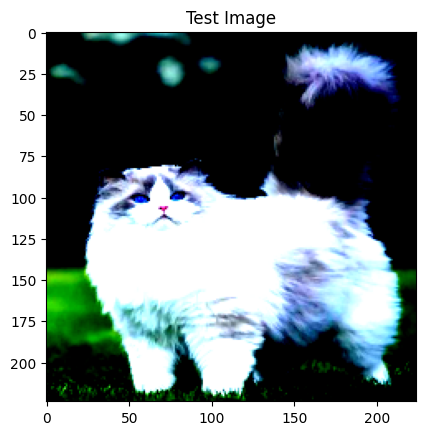

In [95]:
plt.imshow(image.cpu().permute(1, 2, 0))
plt.title("Test Image")
plt.show()

# Saving Model architecture so we dont Have to rerun again and again

In [98]:
torch.save(model.state_dict(), "cat vs Dog/model.pth")

import os
os.makedirs("saved_models", exist_ok=True)

In [ ]:
# Command to load folder

# model.load_state_dict(torch.load("saved_models/model.pth"))